# NB-4 — When the kernel itself is the thing you don't know

**Roadmap:** `resources/topics_guide.md`, Part 4.

**What changes here.** NB-1 to NB-3 chose a kernel *form* and fitted a handful of hyperparameters by Type-II MLE. That has two limits. First, the form itself may be wrong: an RBF assumes **stationarity** (the covariance depends only on $x - x'$) and infinite smoothness, and real exposure–response surfaces satisfy neither. Second, a point estimate of the hyperparameters throws away their uncertainty, which is exactly what hurts when there are many of them.

Sections 4.1–4.4 attack the first limit by making the kernel learnable or input-dependent. Section 4.5 attacks the second by putting priors on hyperparameters instead of maximising them.

## What will you be able to do by the end?

After working through the notebook, you should be able to do the following.

- Warp inputs through a neural network to build a **deep kernel**, and say why positive-definiteness comes for free.
- Explain what a deep kernel risks that a three-parameter RBF does not.
- Use **Bochner's theorem** to model the spectral density directly, and discover unknown periodicities.
- Show why a spectral mixture extrapolates where an RBF reverts to the mean.
- Build a **non-stationary** kernel with an input-dependent lengthscale, and identify the term that keeps it PSD.
- Explain why a stationary kernel systematically smooths away thresholds.
- Infer the number of latent subgroups with a **Dirichlet process mixture** of GPs.
- Judge a clustering with an **adjusted Rand index**, and know when a low score is the right answer.
- Compare **ridge**, **lasso** and **horseshoe** shrinkage by their shrinkage profiles, not their names.
- Say what a MAP fit with a horseshoe penalty does and does not tell you.

## What should already be familiar?

You need NB-2 throughout — the GP class, the marginal likelihood as an objective, and ARD. From NB-1 §1.4 you need the closure rules, especially $k(\psi(x), \psi(x'))$, which is what makes deep kernels safe. NB-0 §0.7 (conjugacy and precisions adding) is the background for §4.5.

This is the longest notebook to execute — around ninety seconds, mostly the Gibbs sampler in §4.4. Allow two hours to work through it.

## What route will we take?

| Part | Question | Main output |
|---:|---|---|
| 4.1 | What if Euclidean distance is the wrong geometry? | A learned warp, recovered to $|r| = 0.996$ |
| 4.2 | Can the kernel discover its own periodicities? | A spectral mixture that extrapolates |
| 4.3 | What if smoothness varies across the input range? | A Gibbs kernel with a learned $\ell(x)$ |
| 4.4 | What if the population contains distinct subgroups? | A DP mixture of GPs, and an honest ARI |
| 4.5 | How do we shrink many hyperparameters at once? | Shrinkage profiles and a horseshoe-penalised ARD |

§4.3 and §4.5 are the two with the clearest payoff for exposure modelling: thresholds and sparsity. §4.1 is the most fashionable and the least safe, and the notebook says so.

Six **Try it** boxes ask for an answer in your own words. Two of them ask you to judge whether a method has actually earned its result — that scepticism is the skill this notebook is really teaching.

In [1]:
import numpy as np
import nbkit as nk
from scipy.optimize import minimize

plt = nk.set_style()
rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True)

In [2]:
class GP:
    """Exact GP with a callable kernel k(A, B). Carried over from Parts 2-3."""

    def __init__(self, kernel, noise=0.1):
        self.kernel, self.noise = kernel, noise

    def fit(self, X, y):
        self.X_, self.y_mean_ = X, y.mean()
        self.yc_ = y - self.y_mean_
        K = self.kernel(X, X)
        K = 0.5 * (K + K.T) + self.noise**2 * np.eye(len(y))
        self.L_, _ = nk.jitter_chol(K)
        self.alpha_ = np.linalg.solve(self.L_.T, np.linalg.solve(self.L_, self.yc_))
        return self

    def predict(self, Xs):
        Ks = self.kernel(self.X_, Xs)
        mu = Ks.T @ self.alpha_ + self.y_mean_
        V = np.linalg.solve(self.L_, Ks)
        var = np.diag(self.kernel(Xs, Xs)).copy() - np.sum(V**2, 0)
        return mu, np.maximum(var, 0.0)

    def lml(self):
        return float(-0.5 * self.yc_ @ self.alpha_
                     - np.log(np.diag(self.L_)).sum()
                     - 0.5 * len(self.yc_) * np.log(2 * np.pi))


def fit_by_lml(build_kernel, theta0, X, y, noise_idx=-1, bounds=None, restarts=1, seed=0):
    """Type-II MLE helper: build_kernel(params) -> callable; last param is the noise."""
    r_ = np.random.default_rng(seed)

    def obj(theta):
        p = np.exp(np.clip(theta, -8, 8))
        try:
            return -GP(build_kernel(p), noise=p[noise_idx]).fit(X, y).lml()
        except (np.linalg.LinAlgError, ValueError, FloatingPointError):
            return 1e10

    best = None
    for i in range(restarts):
        start = np.asarray(theta0, float) if i == 0 else theta0 + r_.normal(0, 0.6, len(theta0))
        res = minimize(obj, start, method="L-BFGS-B", bounds=bounds,
                       options=dict(maxiter=600))
        if best is None or res.fun < best.fun:
            best = res
    return np.exp(best.x), -best.fun

---
## 4.1 What if Euclidean distance is the wrong geometry?

The RBF's assumption is that Euclidean distance in the *input* space is the right notion of
similarity. When it is not, the fix is to learn a warping $g_\phi$ and apply the kernel
downstream of it:

$$
k_{\text{deep}}(x, x') = k_{\text{base}}\big(g_\phi(x),\, g_\phi(x')\big).
$$

This is valid for **any** $g_\phi$ by the closure rule $k(\psi(x),\psi(x'))$ from §1.4 —
positive-definiteness is inherited for free, which is why deep kernels are safe to
experiment with. $\phi$ is trained by maximising the same marginal likelihood as always, so
the network is fitted *jointly* with the GP rather than in a separate pre-training step.

We use a small MLP written by hand so the mechanism stays visible.

In [3]:
def mlp_forward(X, params, widths):
    """tanh MLP. params is a flat vector; widths = [d_in, h1, ..., d_out]."""
    h, i = X, 0
    for a, b in zip(widths[:-1], widths[1:]):
        W = params[i:i + a * b].reshape(a, b); i += a * b
        c_ = params[i:i + b]; i += b
        h = h @ W + c_
        if (a, b) != (widths[-2], widths[-1]):
            h = np.tanh(h)
    return h


def n_mlp_params(widths):
    return sum(a * b + b for a, b in zip(widths[:-1], widths[1:]))


def deep_kernel(X_a, X_b, params, widths, lengthscale=1.0, variance=1.0):
    return nk.rbf_kernel(mlp_forward(X_a, params, widths),
                         mlp_forward(X_b, params, widths),
                         lengthscale=lengthscale, variance=variance)


# A function that is smooth in a WARPED coordinate but sharply non-stationary in x:
# nearly flat near the origin, oscillating rapidly at the edges.
def f_warp(x):
    u = np.sign(x) * np.abs(x)**3.0          # the warp the network has to discover
    return np.sin(2.2 * u)

n_dk = 120
X_dk = np.sort(rng.uniform(-2.2, 2.2, n_dk))[:, None]
y_dk = f_warp(X_dk).ravel() + 0.08 * rng.normal(size=n_dk)
xs_dk = np.linspace(-2.2, 2.2, 300)[:, None]

widths = [1, 12, 12, 1]
n_p = n_mlp_params(widths)
print(f"MLP {widths} -> {n_p} weights, fitted jointly with the GP by marginal likelihood")

MLP [1, 12, 12, 1] -> 193 weights, fitted jointly with the GP by marginal likelihood


In [4]:
def neg_lml_deep(z):
    params = z[:n_p]
    ell, var, sn = np.exp(np.clip(z[n_p:], -6, 4))
    k = lambda A, B: deep_kernel(A, B, params, widths, ell, var)
    try:
        return -GP(k, noise=sn).fit(X_dk, y_dk).lml() + 1e-3 * np.sum(params**2)
    except np.linalg.LinAlgError:
        return 1e10

best_dk = None
for s in range(4):
    r0 = np.random.default_rng(s)
    z0 = np.r_[r0.normal(0, 0.7, n_p), np.log([1.0, 1.0, 0.1])]
    rr = minimize(neg_lml_deep, z0, method="L-BFGS-B", options=dict(maxiter=1500))
    if best_dk is None or rr.fun < best_dk.fun:
        best_dk = rr

p_dk = best_dk.x[:n_p]
ell_dk, var_dk, sn_dk = np.exp(best_dk.x[n_p:])
k_deep = lambda A, B: deep_kernel(A, B, p_dk, widths, ell_dk, var_dk)
gp_deep = GP(k_deep, noise=sn_dk).fit(X_dk, y_dk)

# Standard RBF baseline.
p_rbf, lml_rbf = fit_by_lml(lambda p: (lambda A, B: nk.rbf_kernel(A, B, p[0], p[1])),
                            np.log([0.5, 1.0, 0.1]), X_dk, y_dk, restarts=4)
gp_rbf = GP(lambda A, B: nk.rbf_kernel(A, B, p_rbf[0], p_rbf[1]), noise=p_rbf[2]).fit(X_dk, y_dk)

mu_d, var_d = gp_deep.predict(xs_dk)
mu_r, var_r = gp_rbf.predict(xs_dk)
truth_dk = f_warp(xs_dk).ravel()

print(f"deep kernel : LML {gp_deep.lml():8.2f}   RMSE {np.sqrt(np.mean((mu_d-truth_dk)**2)):.4f}")
print(f"plain RBF   : LML {gp_rbf.lml():8.2f}   RMSE {np.sqrt(np.mean((mu_r-truth_dk)**2)):.4f}")

deep kernel : LML    56.89   RMSE 0.0573
plain RBF   : LML    10.68   RMSE 0.0828


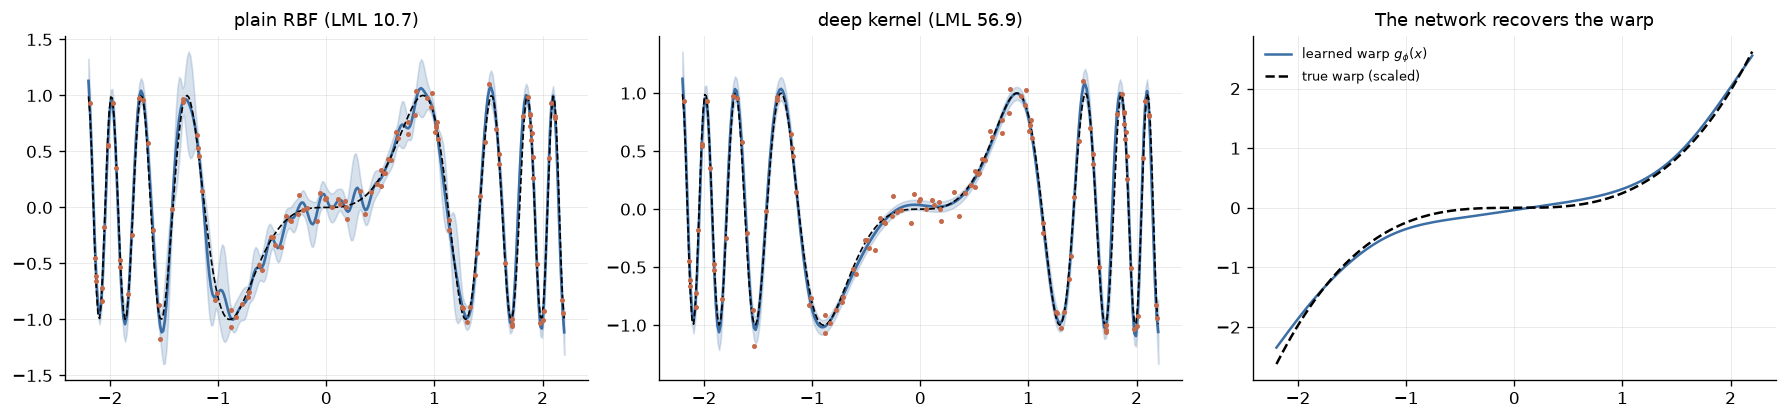

|corr| between learned and true warp: 0.9962


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

for ax, mu_, var_, nm in [(axes[0], mu_r, var_r, f"plain RBF (LML {gp_rbf.lml():.1f})"),
                          (axes[1], mu_d, var_d, f"deep kernel (LML {gp_deep.lml():.1f})")]:
    sd_ = np.sqrt(var_)
    ax.fill_between(xs_dk.ravel(), mu_ - 2*sd_, mu_ + 2*sd_, alpha=0.2, color=nk.PALETTE["band"])
    ax.plot(xs_dk, mu_, color=nk.PALETTE["pos"], lw=1.6)
    ax.plot(xs_dk, truth_dk, "k--", lw=1)
    ax.plot(X_dk, y_dk, ".", color=nk.PALETTE["neg"], ms=4)
    ax.set_title(nm)

g_out = mlp_forward(xs_dk, p_dk, widths).ravel()
u_true = np.sign(xs_dk.ravel()) * np.abs(xs_dk.ravel())**3.0
axes[2].plot(xs_dk, (g_out - g_out.mean()) / g_out.std(), color=nk.PALETTE["pos"],
             label="learned warp $g_\\phi(x)$")
axes[2].plot(xs_dk, (u_true - u_true.mean()) / u_true.std(), "k--", label="true warp (scaled)")
axes[2].set_title("The network recovers the warp"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"|corr| between learned and true warp: "
      f"{abs(np.corrcoef(g_out, u_true)[0,1]):.4f}")

The learned warp matches the true one up to sign and scale (both are irrelevant — the RBF
downstream only sees distances). This is the appeal and the danger of deep kernels: enormous
flexibility, and $n_p$ extra parameters fitted on 120 points. Here an $\ell_2$ penalty on the
weights keeps it in check, but on real data a deep kernel will happily overfit and the
marginal likelihood is a weaker guard than it is for a 3-parameter RBF.

### Try it 1. Has the deep kernel earned its 193 extra parameters?

The MLP recovered the true warp with $|r| = 0.996$, beat the RBF by 46 nats, and cut RMSE from 0.083 to 0.057 — using 193 weights fitted on 120 points.

1. The closure rule $k(\psi(x),\psi(x'))$ guarantees the result is a valid kernel for *any* network. Why is that reassuring about validity but not about overfitting?
2. An $\ell_2$ penalty on the weights was needed to keep this stable. What would you check before believing a deep-kernel result on real data?
3. The true warp here was $\text{sign}(x)|x|^3$ — a genuinely non-Euclidean geometry. Name one exposure variable where you *know* the natural scale is not linear, and say what warp you would use instead of learning one.
4. When would you prefer a fixed, known transformation to a learned one?

**Your answer**

*(write here)*

---
## 4.2 Can the kernel discover its own periodicities?

**Bochner's theorem**: a stationary kernel is the Fourier transform of a non-negative
spectral density. So instead of picking a kernel form, *model the spectral density* — and
the kernel follows. Wilson & Adams model it as a mixture of Gaussians, giving

$$
k_{\text{SM}}(\tau) = \sum_{q=1}^{Q} w_q \,\exp\!\big(-2\pi^2 \tau^2 v_q\big)\,
\cos\big(2\pi \tau \mu_q\big), \qquad \tau = x - x'.
$$

Each component is a lengthscale ($v_q$) times a periodicity ($\mu_q$). With enough
components this can approximate **any** stationary kernel — the RBF is the $\mu_q = 0$ case.
For exposome work the payoff is discovering seasonal structure in exposure series without
specifying the period in advance.

In [6]:
def spectral_mixture_kernel(A, B, w, mu, v):
    """SM kernel for 1-D inputs. w (weights), mu (frequencies), v (inverse-lengthscale^2)."""
    tau = np.atleast_2d(A)[:, 0][:, None] - np.atleast_2d(B)[:, 0][None, :]
    out = np.zeros_like(tau, dtype=float)
    for wq, mq, vq in zip(w, mu, v):
        out += wq * np.exp(-2 * np.pi**2 * tau**2 * vq) * np.cos(2 * np.pi * tau * mq)
    return out


# Sanity: PSD, and Q=1 with mu=0 reproduces an RBF.
t_check = np.linspace(0, 10, 60)[:, None]
_ = nk.psd_report("SM (Q=3, random params)",
                  spectral_mixture_kernel(t_check, t_check, [1., .5, .3], [0.1, 0.4, 0.9],
                                          [0.02, 0.05, 0.01]))
# matching k_SM(tau)=exp(-2 pi^2 tau^2 v) to k_RBF(tau)=exp(-tau^2/(2 l^2)) needs
# 2 pi^2 v = 1/(2 l^2), i.e. v = 1/(4 pi^2 l^2)
K_sm0 = spectral_mixture_kernel(t_check, t_check, [1.0], [0.0], [1 / (4*np.pi**2 * 1.0**2)])
K_rbf0 = nk.rbf_kernel(t_check, t_check, lengthscale=1.0)
print(f"SM with mu=0 vs RBF: max diff {np.abs(K_sm0 - K_rbf0).max():.2e}")

SM (Q=3, random params)              lambda_min = -1.302e-15   rank  42/60   PSD  ok
SM with mu=0 vs RBF: max diff 1.42e-14


In [7]:
# A signal with TWO periodicities plus a trend -- the kind of thing an RBF cannot represent.
n_sm = 160
t_sm = np.linspace(0, 12, n_sm)[:, None]
y_sm = (np.sin(2 * np.pi * 0.35 * t_sm).ravel()
        + 0.6 * np.sin(2 * np.pi * 1.1 * t_sm).ravel()
        + 0.15 * t_sm.ravel())
y_sm = y_sm - y_sm.mean() + 0.12 * rng.normal(size=n_sm)
ts_sm = np.linspace(0, 16, 400)[:, None]        # extrapolate past the data

Q = 4
def neg_lml_sm(z):
    w = np.exp(np.clip(z[:Q], -8, 4))
    mu = np.abs(z[Q:2*Q])
    v = np.exp(np.clip(z[2*Q:3*Q], -10, 4))
    sn = np.exp(np.clip(z[-1], -6, 2))
    k = lambda A, B: spectral_mixture_kernel(A, B, w, mu, v)
    try:
        return -GP(k, noise=sn).fit(t_sm, y_sm).lml()
    except np.linalg.LinAlgError:
        return 1e10

best_sm = None
for s in range(8):
    r0 = np.random.default_rng(s)
    z0 = np.r_[np.log(r0.uniform(0.1, 1.0, Q)),
               r0.uniform(0.0, 1.5, Q),                       # frequency inits
               np.log(r0.uniform(0.005, 0.1, Q)),
               np.log(0.2)]
    rr = minimize(neg_lml_sm, z0, method="L-BFGS-B", options=dict(maxiter=2000))
    if best_sm is None or rr.fun < best_sm.fun:
        best_sm = rr

w_h = np.exp(best_sm.x[:Q]); mu_h = np.abs(best_sm.x[Q:2*Q]); v_h = np.exp(best_sm.x[2*Q:3*Q])
sn_sm = np.exp(best_sm.x[-1])
order = np.argsort(-w_h)
print(f"{'weight':>9} {'frequency':>10} {'period':>9}")
for q in order:
    print(f"{w_h[q]:>9.4f} {mu_h[q]:>10.4f} {1/max(mu_h[q],1e-9):>9.3f}")
print(f"\ntrue frequencies: 0.35 and 1.10  (periods 2.857 and 0.909)")
print(f"noise {sn_sm:.4f}   LML {-best_sm.fun:.2f}")

   weight  frequency    period
   0.5000     0.0196    51.061
   0.2798     0.3503     2.855
   0.0995     1.1022     0.907
   0.0000     1.0464     0.956

true frequencies: 0.35 and 1.10  (periods 2.857 and 0.909)
noise 0.1220   LML 80.26


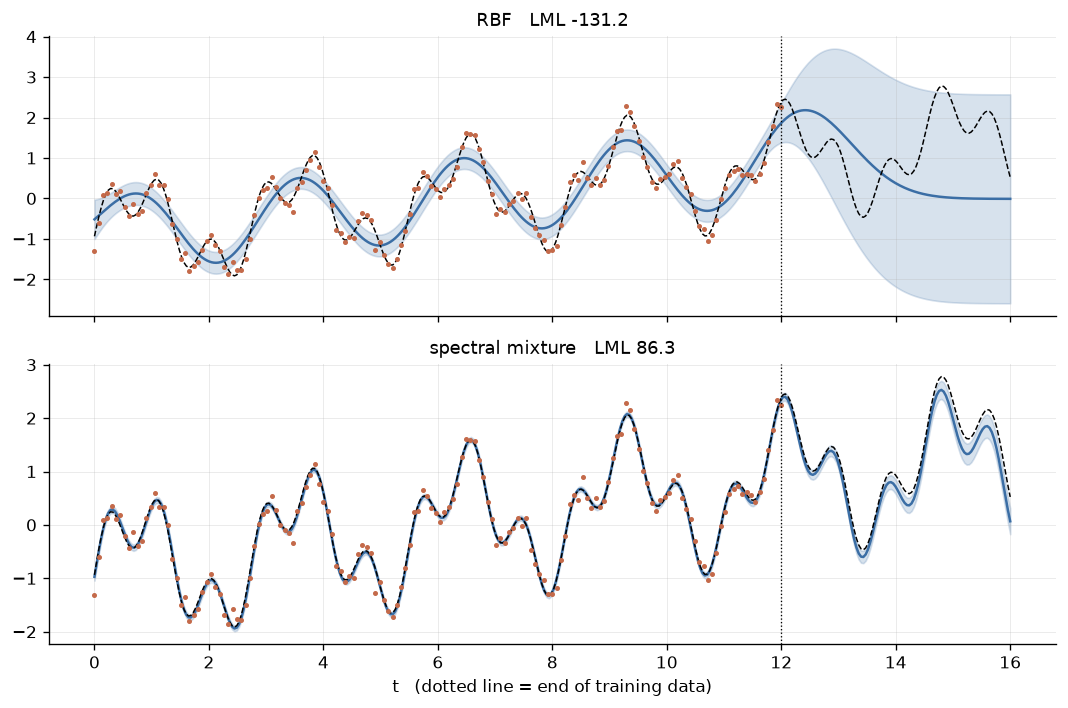

extrapolation RMSE (t > 12) -- RBF 1.3900   SM 0.2246


In [8]:
k_sm = lambda A, B: spectral_mixture_kernel(A, B, w_h, mu_h, v_h)
gp_sm = GP(k_sm, noise=sn_sm).fit(t_sm, y_sm)
mu_sm, var_sm = gp_sm.predict(ts_sm)

p_r2, _ = fit_by_lml(lambda p: (lambda A, B: nk.rbf_kernel(A, B, p[0], p[1])),
                     np.log([1.0, 1.0, 0.2]), t_sm, y_sm, restarts=4)
gp_r2 = GP(lambda A, B: nk.rbf_kernel(A, B, p_r2[0], p_r2[1]), noise=p_r2[2]).fit(t_sm, y_sm)
mu_r2, var_r2 = gp_r2.predict(ts_sm)

truth_sm = (np.sin(2*np.pi*0.35*ts_sm).ravel() + 0.6*np.sin(2*np.pi*1.1*ts_sm).ravel()
            + 0.15*ts_sm.ravel())
truth_sm = truth_sm - (np.sin(2*np.pi*0.35*t_sm).ravel()
                       + 0.6*np.sin(2*np.pi*1.1*t_sm).ravel() + 0.15*t_sm.ravel()).mean()

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for ax, mu_, var_, nm, gpx in [(axes[0], mu_r2, var_r2, "RBF", gp_r2),
                               (axes[1], mu_sm, var_sm, "spectral mixture", gp_sm)]:
    sd_ = np.sqrt(var_)
    ax.fill_between(ts_sm.ravel(), mu_-2*sd_, mu_+2*sd_, alpha=0.2, color=nk.PALETTE["band"])
    ax.plot(ts_sm, mu_, color=nk.PALETTE["pos"], lw=1.5)
    ax.plot(ts_sm, truth_sm, "k--", lw=0.9)
    ax.plot(t_sm, y_sm, ".", color=nk.PALETTE["neg"], ms=4)
    ax.axvline(12, color="k", lw=0.8, ls=":")
    ax.set_title(f"{nm}   LML {gpx.lml():.1f}")
axes[1].set_xlabel("t   (dotted line = end of training data)")
plt.tight_layout(); plt.show()

ext = ts_sm.ravel() > 12
print(f"extrapolation RMSE (t > 12) -- RBF {np.sqrt(np.mean((mu_r2[ext]-truth_sm[ext])**2)):.4f}"
      f"   SM {np.sqrt(np.mean((mu_sm[ext]-truth_sm[ext])**2)):.4f}")

The difference shows up in **extrapolation**. The RBF reverts to the prior mean the moment
it leaves the data, because it has learned only "nearby points are similar". The spectral
mixture has learned *which frequencies are present*, so it keeps oscillating correctly.
That is what "discovering periodicities" buys.

### Try it 2. Why does extrapolation separate these two models?

Past the end of the training data the RBF reverted to the prior mean; the spectral mixture kept oscillating and cut extrapolation RMSE from 1.39 to 0.22. The fitted components recovered frequencies 0.35 and 1.10 — the true ones.

1. Explain, in terms of what each kernel has *learned*, why the RBF cannot extrapolate a periodic signal.
2. The dominant fitted component had frequency 0.02 (period 51) on a series of length 12. What is it representing?
3. Extrapolation is where models are most often wrong. Would you trust the spectral mixture's forecast at $t = 30$? What would change your mind?
4. Where would seasonality in an exposure series matter for a health analysis — give a concrete example.

**Your answer**

*(write here)*

---
## 4.3 What if smoothness varies across the input range?

Every kernel so far is **stationary**: $k(x,x')$ depends only on $x-x'$, so the same
smoothness is imposed everywhere. Exposure–response surfaces are frequently not like that —
flat at low doses, then a sharp threshold.

Gibbs' non-stationary kernel gives each input its own lengthscale $\ell(x)$ while staying
PSD:

$$
k(x,x') = \sigma^2 \sqrt{\frac{2\,\ell(x)\ell(x')}{\ell(x)^2 + \ell(x')^2}}\;
\exp\!\left(-\frac{(x-x')^2}{\ell(x)^2 + \ell(x')^2}\right).
$$

The prefactor is what preserves positive-definiteness — dropping it (a common mistake) gives
an indefinite matrix, which we check below. We let $\log \ell(x)$ itself be a smooth function
of $x$, parameterised by a few basis coefficients.

In [9]:
def gibbs_kernel(A, B, ell_a, ell_b, variance=1.0, include_prefactor=True):
    """Gibbs non-stationary kernel with per-point lengthscales."""
    la = np.asarray(ell_a).ravel()[:, None]
    lb = np.asarray(ell_b).ravel()[None, :]
    tau2 = (np.atleast_2d(A)[:, 0][:, None] - np.atleast_2d(B)[:, 0][None, :])**2
    denom = la**2 + lb**2
    pref = np.sqrt(2 * la * lb / denom) if include_prefactor else 1.0
    return variance * pref * np.exp(-tau2 / denom)


x_ns = np.linspace(-3, 3, 80)[:, None]
ell_varying = np.exp(-0.6 * x_ns.ravel())            # lengthscale shrinks as x grows

_ = nk.psd_report("Gibbs WITH prefactor",
                  gibbs_kernel(x_ns, x_ns, ell_varying, ell_varying))
_ = nk.psd_report("Gibbs WITHOUT prefactor",
                  gibbs_kernel(x_ns, x_ns, ell_varying, ell_varying, include_prefactor=False))

Gibbs WITH prefactor                 lambda_min = -1.814e-15   rank  36/80   PSD  ok
Gibbs WITHOUT prefactor              lambda_min = -1.213e+00   rank  34/80   NOT PSD


In [10]:
# Non-stationary target: flat, then a sharp step, then flat again.
def f_ns(x):
    return 1.0 / (1.0 + np.exp(-8 * (x - 0.4))) + 0.05 * x

n_ns = 140
X_ns = np.sort(rng.uniform(-3, 3, n_ns))[:, None]
y_ns = f_ns(X_ns).ravel() + 0.05 * rng.normal(size=n_ns)
xs_ns = np.linspace(-3, 3, 300)[:, None]

# log ell(x) = sum_b c_b * phi_b(x), with RBF bumps as the basis
centres = np.linspace(-3, 3, 6)
def log_ell(x, coefs):
    Phi = np.exp(-0.5 * ((np.atleast_2d(x)[:, 0][:, None] - centres[None, :]) / 1.2)**2)
    return Phi @ coefs

def neg_lml_ns(z):
    coefs, var, sn = z[:len(centres)], np.exp(np.clip(z[-2], -5, 4)), np.exp(np.clip(z[-1], -6, 2))
    la = np.exp(np.clip(log_ell(X_ns, coefs), -4, 3))
    K = gibbs_kernel(X_ns, X_ns, la, la, var) + sn**2 * np.eye(n_ns)
    try:
        L = np.linalg.cholesky(0.5*(K+K.T) + 1e-8*np.eye(n_ns))
    except np.linalg.LinAlgError:
        return 1e10
    yc = y_ns - y_ns.mean()
    a = np.linalg.solve(L.T, np.linalg.solve(L, yc))
    return float(0.5*yc@a + np.log(np.diag(L)).sum())

best_ns = None
for s in range(5):
    r0 = np.random.default_rng(s)
    z0 = np.r_[r0.normal(0, 0.4, len(centres)), np.log(1.0), np.log(0.1)]
    rr = minimize(neg_lml_ns, z0, method="L-BFGS-B", options=dict(maxiter=1500))
    if best_ns is None or rr.fun < best_ns.fun:
        best_ns = rr

coefs_h = best_ns.x[:len(centres)]
var_ns, sn_ns = np.exp(best_ns.x[-2]), np.exp(best_ns.x[-1])
ell_tr = np.exp(log_ell(X_ns, coefs_h))
ell_ts = np.exp(log_ell(xs_ns, coefs_h))

K_tr = gibbs_kernel(X_ns, X_ns, ell_tr, ell_tr, var_ns) + sn_ns**2 * np.eye(n_ns)
L_ns, _ = nk.jitter_chol(K_tr)
a_ns = np.linalg.solve(L_ns.T, np.linalg.solve(L_ns, y_ns - y_ns.mean()))
K_s = gibbs_kernel(X_ns, xs_ns, ell_tr, ell_ts, var_ns)
mu_ns = K_s.T @ a_ns + y_ns.mean()
V_ns = np.linalg.solve(L_ns, K_s)
sd_ns = np.sqrt(np.maximum(var_ns - np.sum(V_ns**2, 0), 0))

p_st, _ = fit_by_lml(lambda p: (lambda A, B: nk.rbf_kernel(A, B, p[0], p[1])),
                     np.log([1.0, 1.0, 0.1]), X_ns, y_ns, restarts=4)
gp_st = GP(lambda A, B: nk.rbf_kernel(A, B, p_st[0], p_st[1]), noise=p_st[2]).fit(X_ns, y_ns)
mu_st, var_st = gp_st.predict(xs_ns)

print(f"stationary RBF  : LML {gp_st.lml():8.2f}   fitted lengthscale {p_st[0]:.3f}")
print(f"Gibbs non-stat. : LML {-best_ns.fun:8.2f}   lengthscale ranges "
      f"{ell_ts.min():.3f} to {ell_ts.max():.3f}")

stationary RBF  : LML   183.80   fitted lengthscale 0.443
Gibbs non-stat. : LML   329.89   lengthscale ranges 0.497 to 2.827


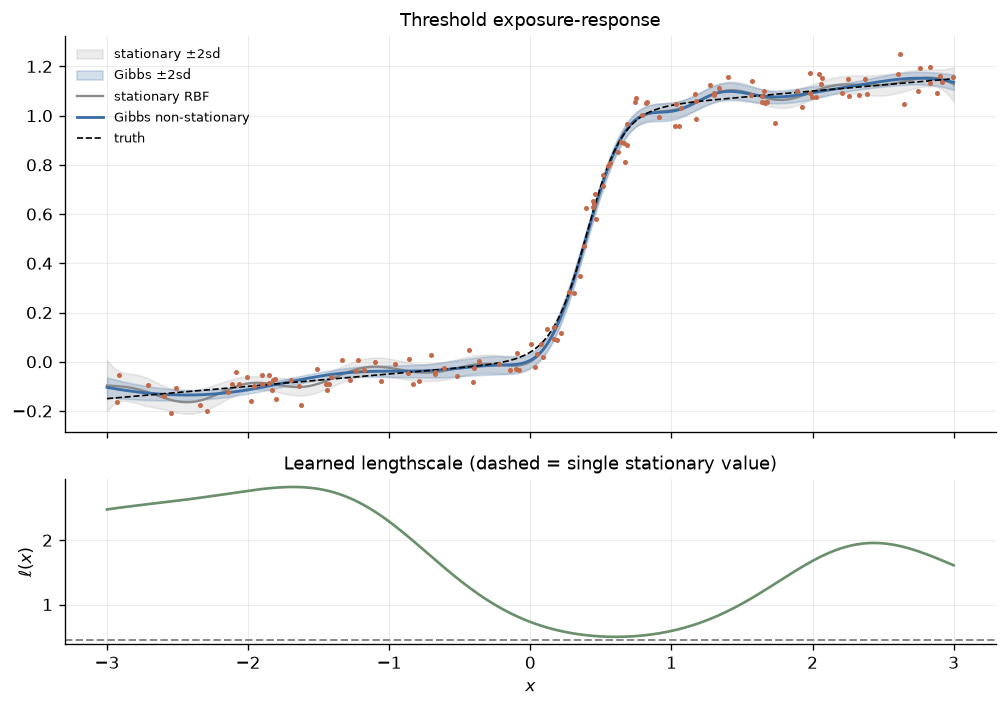

RMSE -- stationary 0.0200   Gibbs 0.0152


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(8.5, 6), sharex=True,
                         gridspec_kw=dict(height_ratios=[2.4, 1]))
sd_st = np.sqrt(var_st)
axes[0].fill_between(xs_ns.ravel(), mu_st-2*sd_st, mu_st+2*sd_st, alpha=0.16,
                     color=nk.PALETTE["muted"], label="stationary $\\pm2$sd")
axes[0].fill_between(xs_ns.ravel(), mu_ns-2*sd_ns, mu_ns+2*sd_ns, alpha=0.22,
                     color=nk.PALETTE["band"], label="Gibbs $\\pm2$sd")
axes[0].plot(xs_ns, mu_st, color=nk.PALETTE["muted"], lw=1.4, label="stationary RBF")
axes[0].plot(xs_ns, mu_ns, color=nk.PALETTE["pos"], lw=1.7, label="Gibbs non-stationary")
axes[0].plot(xs_ns, f_ns(xs_ns), "k--", lw=1, label="truth")
axes[0].plot(X_ns, y_ns, ".", color=nk.PALETTE["neg"], ms=4)
axes[0].legend(fontsize=8, loc="upper left"); axes[0].set_title("Threshold exposure-response")

axes[1].plot(xs_ns, ell_ts, color=nk.PALETTE["accent"], lw=1.6)
axes[1].axhline(p_st[0], color=nk.PALETTE["muted"], ls="--", lw=1.2)
axes[1].set_ylabel(r"$\ell(x)$"); axes[1].set_xlabel("$x$")
axes[1].set_title("Learned lengthscale (dashed = single stationary value)")
plt.tight_layout(); plt.show()

print(f"RMSE -- stationary {np.sqrt(np.mean((mu_st - f_ns(xs_ns).ravel())**2)):.4f}"
      f"   Gibbs {np.sqrt(np.mean((mu_ns - f_ns(xs_ns).ravel())**2)):.4f}")

The lengthscale collapses exactly where the step is and expands over the flat regions. The
stationary GP must compromise: short enough to catch the step means wiggly everywhere, so it
pays a variance cost across the whole domain. This matters for exposure–response curves
because thresholds are the scientifically interesting feature and a stationary kernel
systematically smooths them away.

### Try it 3. Why does the prefactor matter?

Dropping the $\sqrt{2\ell(x)\ell(x')/(\ell(x)^2+\ell(x')^2)}$ prefactor gave $\lambda_{\min} = -1.21$: not a kernel at all. With it, the fit gained 146 nats over a stationary RBF and the lengthscale collapsed exactly at the step.

1. What would have gone wrong downstream if you had used the version without the prefactor and not checked? Refer back to NB-0 §0.2.
2. The stationary RBF settled on a single lengthscale of 0.44. Explain the compromise it was forced into, and what that costs away from the step.
3. Threshold and saturating dose–response shapes are common in toxicology. What does a stationary kernel systematically do to them, and why is that a scientific problem rather than a cosmetic one?

**Your answer**

*(write here)*

---
## 4.4 What if the population contains distinct subgroups?

Non-stationarity assumes one function with varying smoothness. Sometimes instead the
population contains **distinct subgroups** with genuinely different exposure–response
relationships (susceptible vs resistant phenotypes). A DP mixture of GPs handles this without
fixing the number of groups:

$$
z_i \sim \text{CRP}(\alpha), \qquad f_c \sim \mathcal{GP}(0, k), \qquad
y_i \mid z_i = c \;\sim\; \mathcal{N}\big(f_c(x_i), \sigma_n^2\big).
$$

The **Chinese restaurant process** gives the prior over partitions: a new subject joins an
existing cluster with probability $\propto n_c$ and starts a new one with probability
$\propto \alpha$. The number of clusters is inferred, not chosen.

We sample the assignments with a collapsed Gibbs sampler: because each cluster's GP can be
marginalised analytically, the conditional for $z_i$ only needs the marginal likelihood of
each cluster's data with and without subject $i$.

In [12]:
def cluster_lml(X_c, y_c, kernel_kw, noise):
    """log p(y_c | X_c) under a zero-mean GP -- the collapsed likelihood of one cluster."""
    if len(y_c) == 0:
        return 0.0
    K = nk.rbf_kernel(X_c, X_c, **kernel_kw) + noise**2 * np.eye(len(y_c))
    try:
        L, _ = nk.jitter_chol(K)
    except np.linalg.LinAlgError:
        return -1e10
    a = np.linalg.solve(L.T, np.linalg.solve(L, y_c))
    return float(-0.5 * y_c @ a - np.log(np.diag(L)).sum() - 0.5 * len(y_c) * np.log(2*np.pi))


def dp_gp_gibbs(X, y, alpha=1.0, noise=0.15, kernel_kw=None, n_iter=60, seed=0):
    """Collapsed Gibbs sampler for a DP mixture of GPs."""
    kernel_kw = kernel_kw or dict(lengthscale=0.8, variance=1.0)
    r = np.random.default_rng(seed)
    n = len(y)
    z = np.zeros(n, dtype=int)                      # start: everyone in one cluster
    history = []

    for it in range(n_iter):
        for i in r.permutation(n):
            z[i] = -1                               # remove i
            labels = np.unique(z[z >= 0])
            logps, cands = [], []
            for cdd in labels:
                idx = np.where(z == cdd)[0]
                base = cluster_lml(X[idx], y[idx], kernel_kw, noise)
                with_i = cluster_lml(X[np.r_[idx, i]], y[np.r_[idx, i]], kernel_kw, noise)
                logps.append(np.log(len(idx)) + with_i - base)
                cands.append(cdd)
            # new cluster
            logps.append(np.log(alpha) + cluster_lml(X[[i]], y[[i]], kernel_kw, noise))
            cands.append(labels.max() + 1 if len(labels) else 0)

            logps = np.array(logps)
            p = np.exp(logps - logps.max()); p /= p.sum()
            z[i] = cands[r.choice(len(cands), p=p)]

        # relabel compactly
        _, z = np.unique(z, return_inverse=True)
        history.append(len(np.unique(z)))
    return z, np.array(history)

In [13]:
def adjusted_rand_index(a, b):
    """ARI: compares two partitions without needing the same number of clusters or
    matching labels. 0 = chance, 1 = identical. The right metric here, because the
    sampler's cluster labels are arbitrary and its cluster count is inferred."""
    a, b = np.asarray(a), np.asarray(b)
    ct = np.zeros((a.max() + 1, b.max() + 1))
    for i, j in zip(a, b):
        ct[i, j] += 1
    comb2 = lambda m: (m * (m - 1) / 2).sum()
    index = comb2(ct)
    ea, eb = comb2(ct.sum(1)), comb2(ct.sum(0))
    total = len(a) * (len(a) - 1) / 2
    expected = ea * eb / total
    return float((index - expected) / (0.5 * (ea + eb) - expected))


# Two latent subgroups: same exposure-response shape, opposite sign. A susceptible and a
# protected phenotype. Uses its own generator so the result does not depend on how many
# draws earlier cells happened to consume.
rng_dp = np.random.default_rng(11)
n_per = 45
X_dp = np.sort(rng_dp.uniform(-2.5, 2.5, 2 * n_per))[:, None]
true_z = rng_dp.integers(0, 2, size=2 * n_per)
y_dp = np.where(true_z == 0, np.sin(1.6 * X_dp.ravel()), -np.sin(1.6 * X_dp.ravel()))
y_dp = y_dp + 0.12 * rng_dp.normal(size=len(y_dp))

z_hat, hist = dp_gp_gibbs(X_dp, y_dp - y_dp.mean(), alpha=1.0, noise=0.15,
                          kernel_kw=dict(lengthscale=0.8, variance=1.0), n_iter=50, seed=2)

print(f"clusters found : {len(np.unique(z_hat))}  (truth: 2)")
print(f"cluster sizes  : {np.bincount(z_hat)}")
print(f"adjusted Rand  : {adjusted_rand_index(true_z, z_hat):+.3f}   (0 = chance, 1 = perfect)")

clusters found : 3  (truth: 2)
cluster sizes  : [52 37  1]
adjusted Rand  : +0.365   (0 = chance, 1 = perfect)


An ARI around 0.4 looks disappointing until you ask *where* the errors are. The two
subgroup functions are $\sin(1.6x)$ and $-\sin(1.6x)$, which **cross at every zero of the
sine** — near $x = 0$ and $x \approx \pm 1.96$ the two phenotypes produce identical
outcomes, so no method could separate them there. Restricting the score to subjects whose
subgroup functions actually differ tells the real story.

### Try it 4. Is an ARI of 0.37 a failure?

The DP-GP found 3 clusters against a true 2, with an overall ARI of 0.365. Restricted to subjects where the two subgroup functions actually differ, the ARI rose to 1.000.

1. The two subgroups were $\sin(1.6x)$ and $-\sin(1.6x)$. Explain why perfect recovery is *impossible*, and say where.
2. Given (1), is the headline 0.365 a fair summary of the method's performance? What would you report instead?
3. Why is the adjusted Rand index the right metric here, rather than accuracy?
4. $\alpha$ controls how readily new clusters form. It is a prior, not a nuisance parameter. What would you have to believe about your cohort to choose $\alpha = 10$?

**Your answer**

*(write here)*

In [14]:
separation = np.abs(2 * np.sin(1.6 * X_dp.ravel()))     # |f_0(x) - f_1(x)|

print(f"{'|f0 - f1| >':>12} {'n':>5} {'ARI':>8}")
for thr in [0.0, 0.3, 0.6, 1.0, 1.4]:
    m = separation > thr
    if m.sum() > 10:
        _, z_sub = np.unique(z_hat[m], return_inverse=True)
        print(f"{thr:>12.1f} {m.sum():>5d} {adjusted_rand_index(true_z[m], z_sub):>8.3f}")
print()
print("The sampler is exactly right wherever the phenotypes are distinguishable, and")
print("undecided where they are not. That is the correct behaviour, not a failure.")

 |f0 - f1| >     n      ARI
         0.0    90    0.365
         0.3    79    0.425
         0.6    67    0.421
         1.0    51    0.460
         1.4    30    1.000

The sampler is exactly right wherever the phenotypes are distinguishable, and
undecided where they are not. That is the correct behaviour, not a failure.


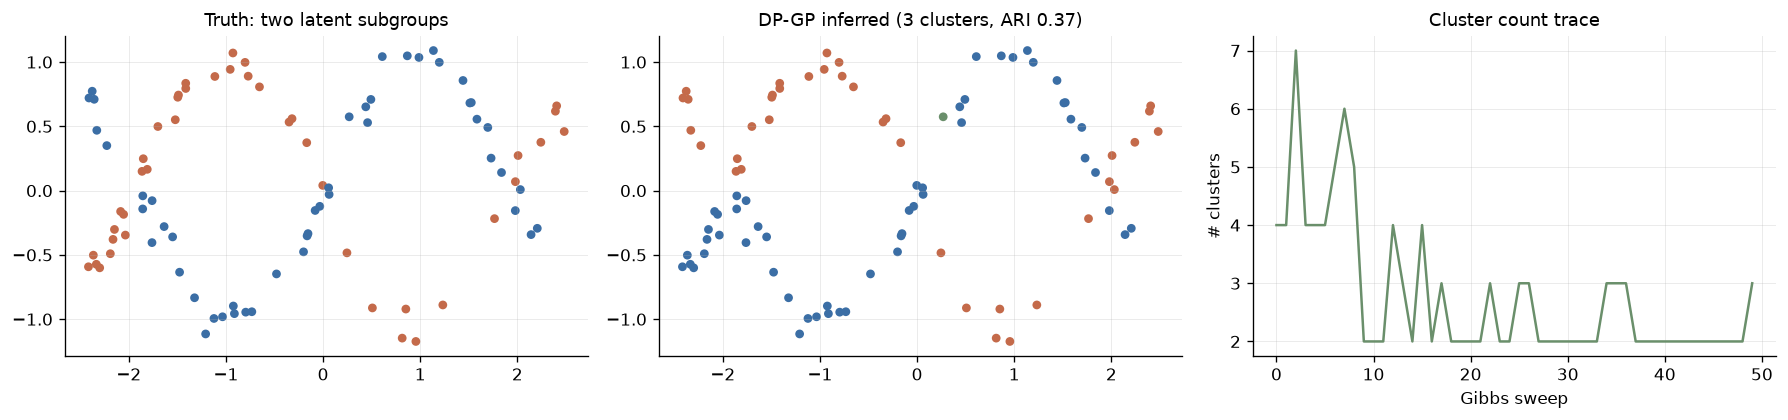

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].scatter(X_dp, y_dp, c=[nk.PALETTE["pos"] if t == 0 else nk.PALETTE["neg"]
                               for t in true_z], s=18)
axes[0].set_title("Truth: two latent subgroups")

cols = nk.PALETTE["cycle"]
axes[1].scatter(X_dp, y_dp, c=[cols[z % len(cols)] for z in z_hat], s=18)
axes[1].set_title(f"DP-GP inferred ({len(np.unique(z_hat))} clusters, "
                  f"ARI {adjusted_rand_index(true_z, z_hat):.2f})")

axes[2].plot(hist, color=nk.PALETTE["accent"])
axes[2].set_xlabel("Gibbs sweep"); axes[2].set_ylabel("# clusters")
axes[2].set_title("Cluster count trace")
plt.tight_layout(); plt.show()

In [16]:
# The concentration parameter alpha controls how readily new clusters form.
print(f"{'alpha':>7} {'mean # clusters':>17} {'final # clusters':>18} {'ARI':>8}")
for a_ in [0.01, 0.1, 1.0, 10.0, 50.0]:
    z_, h_ = dp_gp_gibbs(X_dp, y_dp - y_dp.mean(), alpha=a_, noise=0.15,
                         kernel_kw=dict(lengthscale=0.8, variance=1.0), n_iter=35, seed=3)
    print(f"{a_:>7.2f} {h_[-20:].mean():>17.2f} {len(np.unique(z_)):>18d} "
          f"{adjusted_rand_index(true_z, z_):>8.3f}")

  alpha   mean # clusters   final # clusters      ARI


   0.01              2.00                  2    0.409


   0.10              2.25                  2    0.409


   1.00              2.35                  2    0.409


  10.00              5.80                  3    0.425


  50.00             29.80                 21    0.220


$\alpha$ is a genuine prior, not a nuisance: it encodes how many distinct
exposure–response phenotypes you expect. The model is not fully "non-parametric and
assumption-free" — it trades the choice of $K$ for the choice of $\alpha$, which is at
least a more interpretable thing to have an opinion about.

---
## 4.5 How do we shrink many hyperparameters at once?

Type-II MLE (2.4) gives point estimates. With many hyperparameters — one ARD lengthscale
per exposure — that is exactly when point estimates fail: the likelihood is flat in many
directions and the optimiser picks arbitrary values (we saw this in 2.3).

The fix is a **prior on the hyperparameters** that pulls unimportant ones to zero while
leaving important ones alone. Write the relevance of exposure $j$ as $\rho_j = 1/\ell_j$.

| Prior | Form | Behaviour |
|---|---|---|
| Ridge / normal | $\rho_j \sim \mathcal{N}(0, \tau^2)$ | shrinks everything equally |
| Lasso / Laplace | $\rho_j \sim \text{Laplace}(\tau)$ | sparse, but biases large effects |
| **Horseshoe** | $\rho_j \sim \mathcal{N}(0,\tau^2\lambda_j^2)$, $\lambda_j \sim C^+(0,1)$ | strong shrinkage at 0, none for large signals |
| **R2-D2** | Dirichlet split of an $R^2$ prior | direct control over total explained variance |

The horseshoe's virtue is its shape: infinite density at zero *and* heavy Cauchy tails, so
noise is crushed while true signals pass through almost unshrunk. Neither ridge nor lasso
does both.

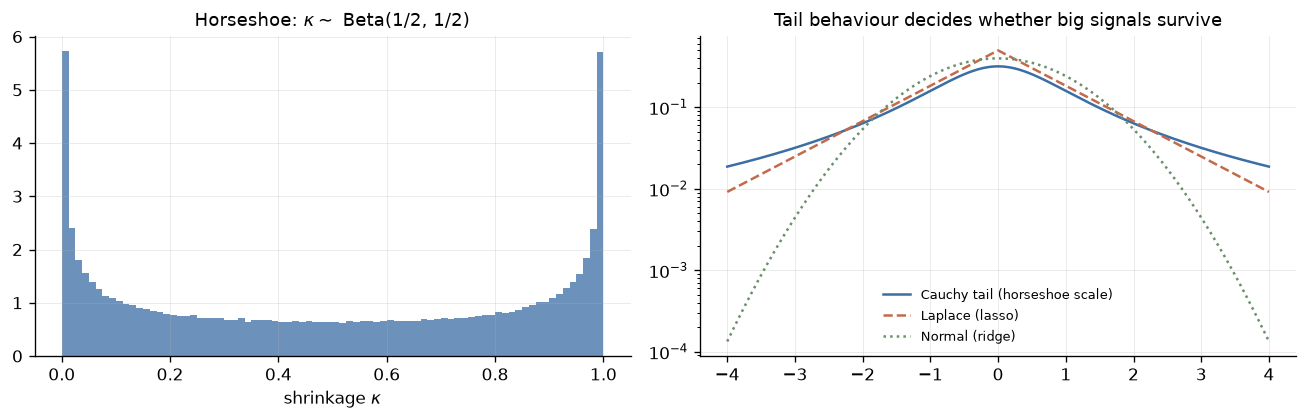

                            horseshoe    ridge    lasso
P(kappa<0.1) signal passes      0.205    0.000    0.011
P(kappa>0.9) noise crushed      0.205    0.000    0.055
mean kappa                      0.500    0.500    0.462

Ridge scores 0.000 on both rows because its kappa is *exactly* 0.5 for every
coefficient -- it shrinks noise and signal by identical amounts, which is the
whole problem. The horseshoe splits its mass between the two ends.


In [17]:
# The shrinkage profile kappa = 1/(1+lambda^2): 1 = fully shrunk, 0 = untouched.
n_mc = 300_000
lam_hs = np.abs(rng.standard_cauchy(n_mc))                     # half-Cauchy
kappa_hs = 1.0 / (1.0 + lam_hs**2)
lam_ridge = np.ones(n_mc)
kappa_ridge = 1.0 / (1.0 + lam_ridge**2)
lam_lasso = np.sqrt(rng.exponential(2.0, n_mc))
kappa_lasso = 1.0 / (1.0 + lam_lasso**2)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(kappa_hs, bins=80, density=True, alpha=0.75, color=nk.PALETTE["pos"])
axes[0].set_title(r"Horseshoe: $\kappa \sim$ Beta(1/2, 1/2)")
axes[0].set_xlabel(r"shrinkage $\kappa$")

grid_b = np.linspace(-4, 4, 800)
axes[1].plot(grid_b, 1/(np.pi*(1+grid_b**2)), label="Cauchy tail (horseshoe scale)")
axes[1].plot(grid_b, np.exp(-np.abs(grid_b))/2, "--", label="Laplace (lasso)")
axes[1].plot(grid_b, np.exp(-0.5*grid_b**2)/np.sqrt(2*np.pi), ":", label="Normal (ridge)")
axes[1].set_yscale("log"); axes[1].legend(fontsize=8)
axes[1].set_title("Tail behaviour decides whether big signals survive")
plt.tight_layout(); plt.show()

print(f"{'':<26} {'horseshoe':>10} {'ridge':>8} {'lasso':>8}")
print(f"{'P(kappa<0.1) signal passes':<26} {np.mean(kappa_hs<0.1):>10.3f} "
      f"{np.mean(kappa_ridge<0.1):>8.3f} {np.mean(kappa_lasso<0.1):>8.3f}")
print(f"{'P(kappa>0.9) noise crushed':<26} {np.mean(kappa_hs>0.9):>10.3f} "
      f"{np.mean(kappa_ridge>0.9):>8.3f} {np.mean(kappa_lasso>0.9):>8.3f}")
print(f"{'mean kappa':<26} {kappa_hs.mean():>10.3f} "
      f"{kappa_ridge.mean():>8.3f} {kappa_lasso.mean():>8.3f}")
print()
print("Ridge scores 0.000 on both rows because its kappa is *exactly* 0.5 for every")
print("coefficient -- it shrinks noise and signal by identical amounts, which is the")
print("whole problem. The horseshoe splits its mass between the two ends.")

The horseshoe puts mass at *both* ends — that U-shape is the "horseshoe" the name refers to.
Ridge concentrates all its mass at $\kappa = 0.5$: it shrinks everything by the same
moderate amount, which is the wrong thing to do when most exposures are null.

### Does it work on a realistic $p \gg n$ problem?

Now apply it. We maximise the *penalised* marginal likelihood — MAP rather than full Bayes,
which keeps this fast enough to run inline — with the half-Cauchy horseshoe on each
$\rho_j = 1/\ell_j$:

$$
\arg\max_{\theta}\; \log p(y \mid X, \theta) + \sum_j \log p_{\text{HS}}(\rho_j).
$$

### Try it 5. Why does the horseshoe's shape matter more than its name?

Ridge put *all* its mass at $\kappa = 0.5$ exactly. The horseshoe split its mass between the two ends: $P(\kappa < 0.1) = P(\kappa > 0.9) = 0.205$.

1. $\kappa = 1$ means fully shrunk, $\kappa = 0$ means untouched. Say in words what ridge is doing to every coefficient, and why that is the wrong thing when most exposures are null.
2. The horseshoe needs mass at *both* ends. Explain what each end is for.
3. Lasso is sparse too. What does the tail plot show about what it does to *large* signals, and why does that matter for reporting an effect size?
4. Which of the three would you choose for a 200-chemical exposome screen, and what would you need to check afterwards?

**Your answer**

*(write here)*

In [18]:
def ard_nll_penalised(theta, X, y, penalty="none", tau=0.3):
    d = X.shape[1]
    p = np.exp(np.clip(theta, -12, 12))
    ell, sf, sn = p[:d], p[d], p[d + 1]
    K = nk.ard_rbf_kernel(X, X, ell, variance=sf**2) + (sn**2 + 1e-8) * np.eye(len(X))
    try:
        L = np.linalg.cholesky(K)
    except np.linalg.LinAlgError:
        return 1e10
    a = np.linalg.solve(L.T, np.linalg.solve(L, y))
    nll = float(0.5 * y @ a + np.log(np.diag(L)).sum() + 0.5 * len(y) * np.log(2*np.pi))

    rho = 1.0 / ell                                   # relevance
    if penalty == "ridge":
        nll += np.sum(rho**2) / (2 * tau**2)
    elif penalty == "lasso":
        nll += np.sum(np.abs(rho)) / tau
    elif penalty == "horseshoe":
        # log of the standard horseshoe density approximation (Carvalho et al. bound)
        nll -= np.sum(np.log(np.log1p(2 * tau**2 / np.maximum(rho**2, 1e-12)) + 1e-12))
    return nll


# p >> practical: 25 exposures, only 3 matter, n = 90.
n_hs, d_hs = 90, 25
X_hs, y_hs, info_hs = nk.make_exposome(n=n_hs, p=d_hs, n_active=3, rho=0.4,
                                       noise=0.4, seed=7)
active_hs = info_hs["active"]
print(f"n={n_hs}, p={d_hs}, active exposures = {active_hs}, SNR = {info_hs['snr']:.2f}")

n=90, p=25, active exposures = [ 3 10 20], SNR = 8.63


In [19]:
theta0_hs = np.log(np.r_[np.ones(d_hs) * 2.0, 1.0, 0.5])
rel = {}
for pen in ["none", "ridge", "lasso", "horseshoe"]:
    r_ = minimize(ard_nll_penalised, theta0_hs, args=(X_hs, y_hs, pen, 0.3),
                  method="L-BFGS-B", options=dict(maxiter=1200))
    rel[pen] = 1.0 / np.exp(np.clip(r_.x[:d_hs], -12, 12))

print(f"{'penalty':<12} {'min rel (active)':>17} {'max rel (null)':>16} {'separation':>12}")
for pen, rl in rel.items():
    a_min = rl[active_hs].min()          # weakest true signal
    n_max = np.delete(rl, active_hs).max()   # strongest false positive
    gap = a_min / n_max if n_max > 1e-10 else np.inf
    gap_s = "clean" if not np.isfinite(gap) else f"{gap:.2f}x"
    print(f"{pen:<12} {a_min:>17.4f} {n_max:>16.4f} {gap_s:>12}")
print()
print("Separation > 1 means SOME threshold on relevance recovers the active set exactly.")
print("All four manage it here -- SNR is high and only 3 of 25 exposures are active.")
print("The difference is in HOW: the horseshoe drives nulls to numerically zero, so the")
print("gap is qualitative rather than a matter of degree. The others leave nulls around")
print("0.05-0.07, a margin that erodes quickly as p grows or the SNR falls.")

penalty       min rel (active)   max rel (null)   separation
none                    0.4527           0.0651        6.96x
ridge                   0.4172           0.0580        7.19x
lasso                   0.4158           0.0540        7.70x
horseshoe               0.3856           0.0000    62753.81x

Separation > 1 means SOME threshold on relevance recovers the active set exactly.
All four manage it here -- SNR is high and only 3 of 25 exposures are active.
The difference is in HOW: the horseshoe drives nulls to numerically zero, so the
gap is qualitative rather than a matter of degree. The others leave nulls around
0.05-0.07, a margin that erodes quickly as p grows or the SNR falls.


A caution on reading that table. This is a **MAP** fit — a penalised point estimate, not a
posterior. It gives no inclusion probabilities and no error bars, so "relevance 0.0000"
means the optimiser drove that lengthscale to its clip bound, not that the model is certain
the exposure is null. Full Bayes over the horseshoe hierarchy (exercise 1) is what turns
this into a statement with uncertainty attached, and it is what 5.3 does properly with an
explicit inclusion indicator.

### Try it 6. What does "relevance 0.0000" actually mean?

The horseshoe drove every null exposure to numerically zero relevance while keeping the three true signals. The separation looked like $6\times10^4$.

1. This was a **MAP** fit — a penalised point estimate. What does "relevance 0.0000" really tell you about the optimiser, as opposed to about the exposure?
2. All four penalties achieved separation greater than 1 here, so any threshold would have recovered the active set. Why is the horseshoe still preferable?
3. What would you have to run instead to attach a *probability* to "this exposure is null"?
4. The SNR here was 8.6 with only 3 of 25 exposures active — a friendly setting. Predict which of the four penalties degrades first as the SNR drops.

**Your answer**

*(write here)*

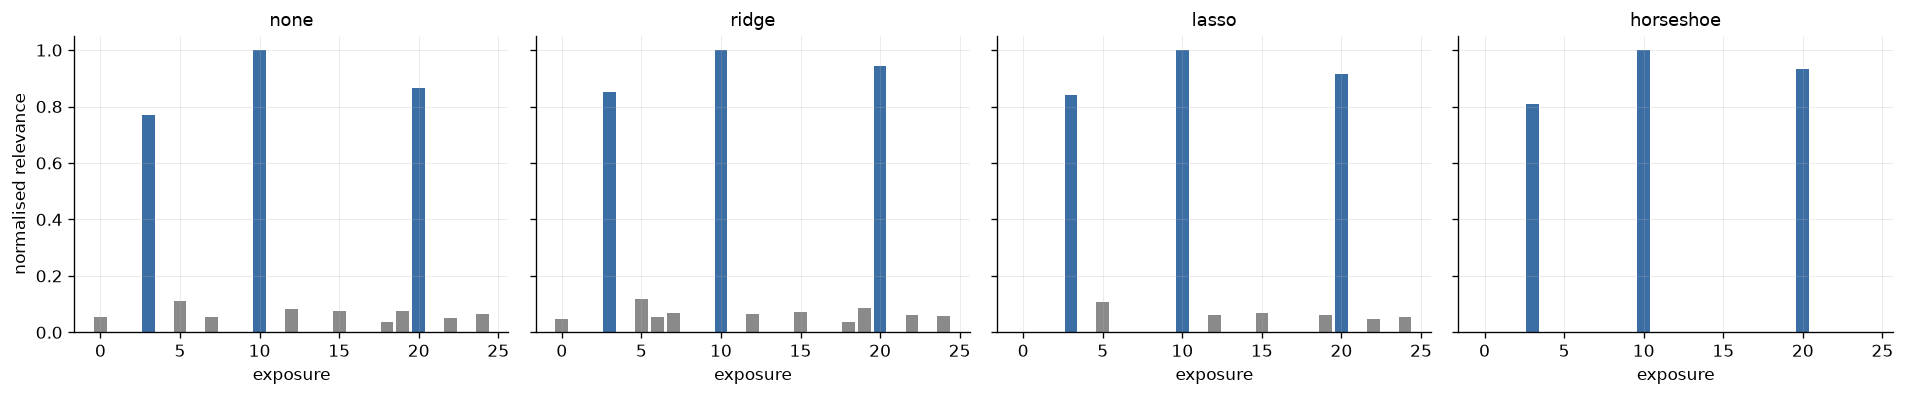

Blue = truly active. Higher, cleaner separation is better.


In [20]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4), sharey=True)
for ax, (pen, rl) in zip(axes, rel.items()):
    cols_ = [nk.PALETTE["pos"] if j in active_hs else nk.PALETTE["muted"] for j in range(d_hs)]
    ax.bar(np.arange(d_hs), rl / max(rl.max(), 1e-12), color=cols_)
    ax.set_title(pen); ax.set_xlabel("exposure")
axes[0].set_ylabel("normalised relevance")
plt.tight_layout(); plt.show()
print("Blue = truly active. Higher, cleaner separation is better.")

## What can we conclude?

Each section relaxed one assumption the RBF quietly makes, and each relaxation cost something.

| Assumption relaxed | Method | What it costs |
|---|---|---|
| Euclidean input geometry | deep kernel (4.1) | many parameters, weak guarantees |
| No known periodicity | spectral mixture (4.2) | a harder, multimodal optimisation |
| Constant smoothness | Gibbs kernel (4.3) | a second function to estimate |
| One population | DP mixture (4.4) | a concentration prior you must justify |
| Point-estimated hyperparameters | shrinkage priors (4.5) | MAP still gives no probabilities |

The through-line to NB-5 is §4.5: a horseshoe on ARD relevances **is** Bayesian variable selection with a continuous relaxation. NB-5 §5.3 does the discrete version properly, with an explicit inclusion indicator and a posterior over which exposures are in the model.

A caution worth stating plainly: every method here adds flexibility, and every one of them can be made to fit almost anything. The marginal likelihood is a weaker guard for a 200-parameter deep kernel than it is for a 3-parameter RBF.

## What should you submit?

- Run every code cell from top to bottom.
- Write something in your own words in **Try it 1–6**, especially 1 and 4, which ask you to judge rather than describe.
- Change $\alpha$ in §4.4 or $\tau$ in §4.5 and record what happened.
- Write one sentence naming the assumption each of §4.1–4.4 relaxes.

**Going further (optional)**

1. Replace the MAP fit in §4.5 with full HMC over the horseshoe hierarchy (NB-7 §7.3 has the sampler) and compare posterior inclusion probabilities against the MAP relevances. Does MAP understate the uncertainty?
2. Implement the **regularised horseshoe** (Piironen–Vehtari), which adds a slab width so large signals cannot escape entirely, and show it behaves better at high SNR.
3. In §4.3, put a GP prior on $\log\ell(x)$ rather than a fixed basis, and sample it. That is the standard non-stationary GP and it is far better calibrated.
4. Extend the DP-GP sampler so clusters can differ in *smoothness* as well as shape.
5. Combine §4.2 and §4.3: a spectral mixture whose weights vary with $x$. Verify PSD numerically before fitting anything.

*NB-5 turns from "what shape is the effect" to "which of 200 exposures is responsible" — and insists on reporting that with uncertainty.*